<div align="center">
    <img src="zzzzimgs/linear_layer.jpg" width="300">
    <br>
    <em></em>
</div>

全微分的定义：如果一个函数被多个变量同时影响，那么这个函数的总变化量是由多个变量引起这个函数变化量的和。

<div align="center">
    <img src="zzzzimgs/linear_backward.jpg" width="300">
    <br>
    <em></em>
</div>

<div align="center">
    <img src="zzzzimgs/linear_backward_delta.jpg" width="700">
    <br>
    <em></em>
</div>


首先，对于 $W_{11}$ 来说，它是第一个输出的 $\delta_1$ 乘以它的输入，梯度的形式是 $\delta_1 \times A_1$。因为有多个 Batch（Batch Size > 1），所以会有多个相同的符号形式，即在不同的 Batch 里的 $\delta_1$ 乘以 $A_1$。

对于 $W_{12}$ 来说，它也是用 $\delta_1 \times A_2$，同样对应多个 Batch。而对于 $W_{21}$ 来说，它是走 $\delta_2$ 那条路径的，所以梯度是 $\delta_2 \times A_1$；$W_{22}$ 的输出则对应 $\delta_2$，其梯度为 $\delta_2 \times A_2$。

其实最后的结果应该是矩阵乘以矩阵的形式。梯度是通过生成每一列、一个一个元素这样生成的，我们希望生成的结果能与 $W$ 的每个参数位置一一对应。也就是说，通过右边矩阵的一列乘以左边矩阵的一行，刚好对应 $W$ 某个位置元素的梯度。这样在做随机梯度下降（SGD）的时候，就可以直接相减进行更新了。

基于这个要求，我们可以观察一下图片右边的这两个矩阵：
1. 如果我们要先求 $W_{11}$ 的参数，就是 $\delta_1 \times A_1$；求 $W_{12}$ 就是 $\delta_1 \times A_2$。
2. 可以观察到 $\delta_1$ 是不变的，变化的是 $A_1$ 和 $A_2$。
3. 在矩阵乘法中，左边矩阵是遍历其行的，右边矩阵的列保持不变。因此，很明显应该把 $A_1, A_2$ 放在左边矩阵，把 $\delta$ 放在右边矩阵。

所以最后的形式就如右图所示。需要说明的是，左边的 $A_1, A_2$ 矩阵需要经过转置。因为原始输入矩阵的形状是 Batch Size（BS）乘以特征维度，为了把 BS 维度变成列的维度，必须做一下转置。

---

对于偏置项（Bias）来说，它其实对应 $W$ 矩阵的某一行。

$W$ 某一行的求法，即求梯度时 $\delta$（delta）和 $A$ 的变化形式是这样的：我们可以观察 $W_{11}$ 和 $W_{21}$，它们是 $\delta$ 在变（例如 $\delta_1 \times A_1$，$\delta_2 \times A_1$）。但对于偏置项来说，它的输入始终都是 1。

因此，从实现上来说，我们只需要：
1. 将整个 $\delta$ 沿着 Batch Size（BS）的维度相加求和。
2. 对求和结果取平均即可。

<div align="center">
    <img src="zzzzimgs/gradient_linear_layer.jpg" width="700">
    <br>
    <em></em>
</div>

我们来说一下，为什么神经网络运行着运行着就发生数值爆炸了，特别是在自己实现深度学习框架的时候。

我们以线性回归作为一个例子，如图所示：

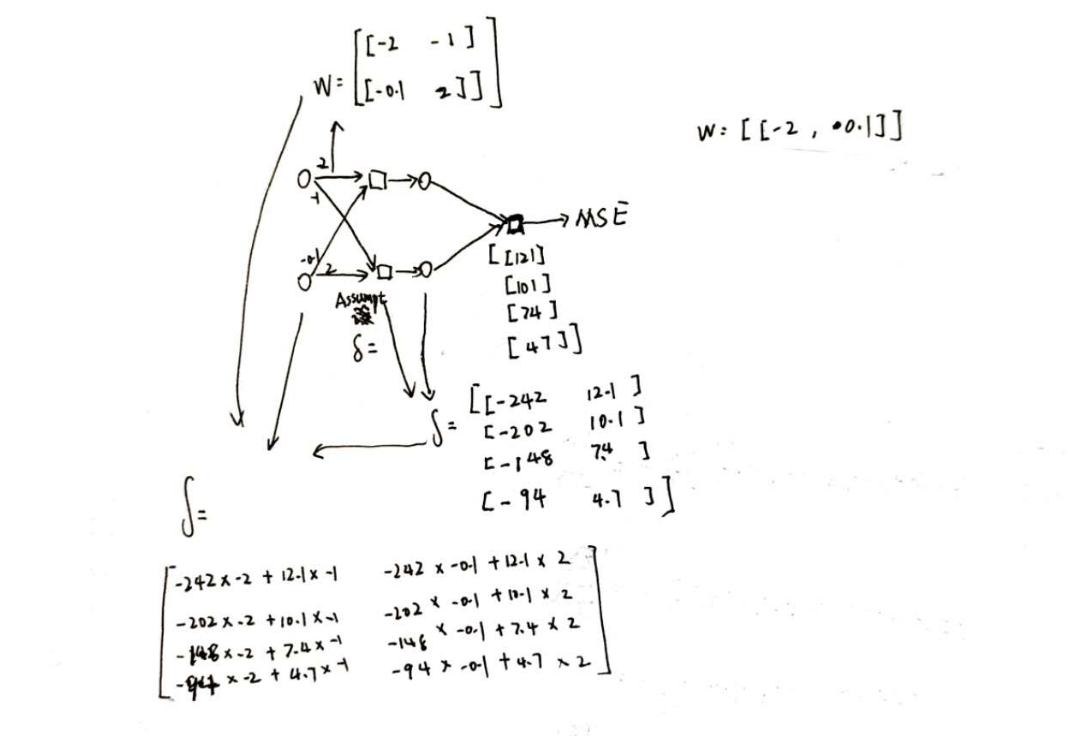

这个例子是一个神经网络的前两层线性层。第一层的输入是两个神经元，输出也是两个神经元；第二层则是输出层，输入是两个神经元，输出是一个神经元。在这里，方格子表示 Logits，小圆圈表示激活值。

我们假设 Batch Size 为 4，且损失函数对神经网络输出的 Logits 的导数值分别是 121、101、74 和 47，这是一个 4×1 的二维矩阵。输出层的参数为一个 1×2 的二维矩阵，它们的值分别是 -2 和 0.1。 这些数值均是从真实项目中截取的真实数值。

这个时候我们求 Delta（δ），即损失函数对输出层输入的偏导：
1. 它等于损失函数对神经网络输出的偏导，乘以输出层输入对应的参数。
2. 对于上面的第一个输入来说，它等于偏导值乘以 -2。计算得到一个 4×1 的向量：-242、-202、-148、-94。
   
   从这里可以看出，如果参数比较大，那么这个Delta 其实会直接翻倍，也就是从 121 变成了 -242。
3. 同样的，对于输出层的第二个输入，它对应的 Delta 就是前面的偏导乘以 0.1。得到一个 4×1 的向量：12.1、10.1、7.4 和 4.7。

此时，我们得到的损失对输出层输入的偏导是一个 4×2 的矩阵。

然后我们继续向后进行反向传播：
1. 假设激活函数是 ReLU，并且在前向传播的时候都是激活状态。那么此时，激活函数输入对应的 Delta 也是那个 4×2 的矩阵。
2. 我们再对第一层线性层的输入求 Delta。假设四个参数分别是 -2、-1、-0.1 和 2。
3. 对于第一层线性层上面的那个输入来说，它的损失函数偏导等于：
   
   (a) 上一层输出对应的所有偏导，乘以 从该神经元 指向所有输出 的对应参数。

   (b) 也就是那个 4×2 矩阵的每一列，分别乘以参数矩阵 W 的每一行，然后做列向求和。

此时我们可以看到，原本已经翻倍的 -242 又翻倍了。 从输出层的输入的偏导，到前一层的输入的损失（也就是对它的偏导），对比它们的数字可以看出：仅仅是经过了一层，那个 Delta 就翻倍了。如果网络越深，显而易见那个 Delta 会变成一个天文数字。这对更新网络的参数来说，会使得参数绝对值变得非常大。